Loaded rows: 2,260,701
Resolved loans: 1,345,350
Default rate: 19.96%


C:\Users\eryaj\AppData\Local\Temp\ipykernel_17164\2065567627.py:40: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["emp_length"] = df["emp_length"].replace(emp_map)
C:\Users\eryaj\AppData\Local\Temp\ipykernel_17164\2065567627.py:51: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["earliest_cr_line"] = pd.to_datetime(df["earliest_cr_line"], errors="coerce")


Final shape: (50000, 21)
Sample default rate: 19.83%


C:\Users\eryaj\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Logistic AUC (test): 0.6804
XGBoost AUC (test): 0.6897
Improvement vs logit: +0.0093


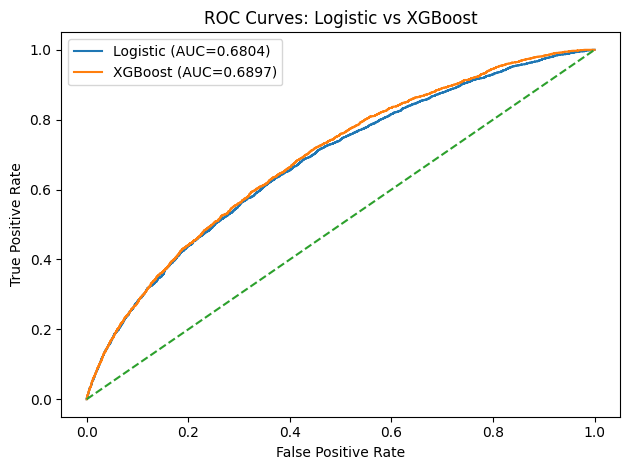

C:\Users\eryaj\AppData\Local\Temp\ipykernel_17164\2065567627.py:179: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grade_bad = pd.Series(y.values).groupby(risk_grade).mean()


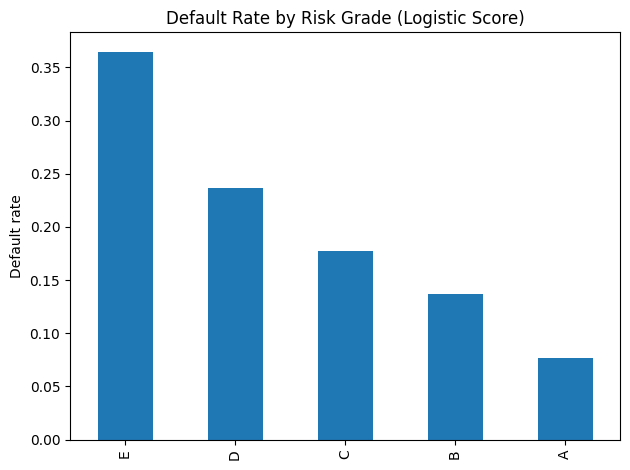

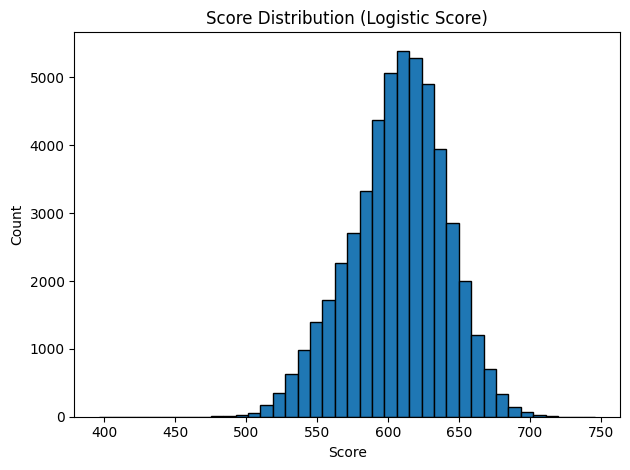


Default rate by grade (logistic score):
E    0.3647
D    0.2362
C    0.1769
B    0.1370
A    0.0769
dtype: float64

Score summary:
count    50000.0
mean       606.7
std         33.5
min        396.5
25%        585.7
50%        609.1
75%        629.9
max        745.6
dtype: float64

Stability (PSI):
PSI on PD (train vs test):   0.0005
PSI on Score (train vs test): 0.0005
Rule of thumb: <0.10 = stable | 0.10-0.25 = monitor | >0.25 = drift

Saved: C:\Users\eryaj\Downloads\lc_credit_risk_logit_xgb_FINAL_WITH_PSI.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
import xgboost as xgb

DATA_PATH = r"C:\Users\eryaj\Downloads\lendingclub.csv"

use_cols = [
    "loan_status", "annual_inc", "emp_length", "home_ownership",
    "revol_util", "delinq_2yrs", "inq_last_6mths", "dti",
    "fico_range_low", "loan_amnt", "term", "earliest_cr_line",
    "pub_rec", "pub_rec_bankruptcies", "acc_now_delinq",
    "open_acc", "total_acc", "mort_acc", "purpose"
]

df = pd.read_csv(DATA_PATH, usecols=use_cols, low_memory=False)
df.columns = df.columns.str.strip()
print(f"Loaded rows: {len(df):,}")

df["default_flag"] = df["loan_status"].isin(["Charged Off", "Default"]).astype(np.int8)
df = df[df["loan_status"].isin(["Fully Paid", "Charged Off", "Default"])].copy()
print(f"Resolved loans: {len(df):,}")
print(f"Default rate: {df['default_flag'].mean():.2%}")

df["term"] = df["term"].astype(str).str.extract(r"(\d+)", expand=False)
df["term"] = pd.to_numeric(df["term"], errors="coerce")

df["revol_util"] = df["revol_util"].astype(str).str.rstrip("%")
df["revol_util"] = pd.to_numeric(df["revol_util"], errors="coerce") / 100.0

emp_map = {
    "< 1 year": 0,
    "1 year": 1, "2 years": 2, "3 years": 3, "4 years": 4,
    "5 years": 5, "6 years": 6, "7 years": 7, "8 years": 8,
    "9 years": 9, "10+ years": 10
}
df["emp_length"] = df["emp_length"].replace(emp_map)

num_cols = [
    "annual_inc", "delinq_2yrs", "inq_last_6mths", "dti",
    "fico_range_low", "loan_amnt", "term",
    "pub_rec", "pub_rec_bankruptcies", "acc_now_delinq",
    "open_acc", "total_acc", "mort_acc", "revol_util"
]
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df["earliest_cr_line"] = pd.to_datetime(df["earliest_cr_line"], errors="coerce")
ref_date = pd.to_datetime("2017-12-01")
df["credit_age_years"] = ((ref_date - df["earliest_cr_line"]).dt.days / 365.25).clip(-5, 80)

df["lti"] = (df["loan_amnt"] / df["annual_inc"]).replace([np.inf, -np.inf], np.nan)
df["open_credit_ratio"] = df["open_acc"] / (df["total_acc"] + 1e-6)

df["annual_inc"] = df["annual_inc"].clip(lower=1, upper=df["annual_inc"].quantile(0.99))
df["dti"] = df["dti"].clip(0, 80)
df["revol_util"] = df["revol_util"].clip(0, 2.0)
df["lti"] = df["lti"].clip(0, 10)

fill_minus1 = ["emp_length", "revol_util", "credit_age_years", "dti", "fico_range_low", "lti",
               "delinq_2yrs", "inq_last_6mths", "loan_amnt", "term"]
for c in fill_minus1:
    df[c] = df[c].fillna(-1)

fill_zero = ["pub_rec", "pub_rec_bankruptcies", "acc_now_delinq", "open_acc", "total_acc", "mort_acc"]
for c in fill_zero:
    df[c] = df[c].fillna(0)

df = df.drop(columns=["earliest_cr_line", "loan_status"], errors="ignore")

if len(df) > 50000:
    df = df.sample(50000, random_state=42).copy()

print("Final shape:", df.shape)
print(f"Sample default rate: {df['default_flag'].mean():.2%}")

y = df["default_flag"].copy()

raw_features = [
    "fico_range_low", "dti", "revol_util", "annual_inc", "credit_age_years",
    "lti", "delinq_2yrs", "inq_last_6mths", "loan_amnt", "term",
    "pub_rec", "pub_rec_bankruptcies", "acc_now_delinq", "open_acc",
    "total_acc", "mort_acc", "open_credit_ratio", "purpose", "home_ownership"
]

X_raw = df[raw_features].copy()

def group_rare(s: pd.Series, min_share=0.01, other="Other") -> pd.Series:
    vc = s.value_counts(normalize=True, dropna=False)
    rare = vc[vc < min_share].index
    return s.where(~s.isin(rare), other).fillna(other)

X_raw["purpose"] = group_rare(X_raw["purpose"], min_share=0.01)
X_raw["home_ownership"] = group_rare(X_raw["home_ownership"], min_share=0.01)

X_raw = pd.get_dummies(X_raw, columns=["term", "purpose", "home_ownership"], drop_first=True)
X_raw = X_raw.replace([np.inf, -np.inf], np.nan)
X_raw = X_raw.fillna(X_raw.median(numeric_only=True))

X_tr, X_te, y_tr, y_te = train_test_split(
    X_raw, y, test_size=0.30, stratify=y, random_state=42
)

X_tr2, X_val, y_tr2, y_val = train_test_split(
    X_tr, y_tr, test_size=0.20, stratify=y_tr, random_state=42
)

logit = LogisticRegression(
    max_iter=10000,
    class_weight="balanced",
    solver="lbfgs",
    random_state=42
)
logit.fit(X_tr, y_tr)

p_logit = logit.predict_proba(X_te)[:, 1]
auc_logit = roc_auc_score(y_te, p_logit)
print(f"\nLogistic AUC (test): {auc_logit:.4f}")

dtrain = xgb.DMatrix(X_tr2, label=y_tr2)
dval = xgb.DMatrix(X_val, label=y_val)
dtest = xgb.DMatrix(X_te, label=y_te)

scale_pos_weight = (y_tr2 == 0).sum() / max(1, (y_tr2 == 1).sum())

params = {
    "objective": "binary:logistic",
    "eval_metric": "auc",
    "learning_rate": 0.03,
    "max_depth": 4,
    "min_child_weight": 10,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "lambda": 1.0,
    "alpha": 0.0,
    "gamma": 0.0,
    "scale_pos_weight": scale_pos_weight,
    "tree_method": "hist",
    "seed": 42
}

bst = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=5000,
    evals=[(dval, "val")],
    early_stopping_rounds=200,
    verbose_eval=False
)

p_xgb = bst.predict(dtest)
auc_xgb = roc_auc_score(y_te, p_xgb)
print(f"XGBoost AUC (test): {auc_xgb:.4f}")
print(f"Improvement vs logit: {auc_xgb - auc_logit:+.4f}")

fpr_l, tpr_l, _ = roc_curve(y_te, p_logit)
fpr_x, tpr_x, _ = roc_curve(y_te, p_xgb)

plt.figure()
plt.plot(fpr_l, tpr_l, label=f"Logistic (AUC={auc_logit:.4f})")
plt.plot(fpr_x, tpr_x, label=f"XGBoost (AUC={auc_xgb:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curves: Logistic vs XGBoost")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.savefig("roc_logistic_vs_xgboost.png", dpi=150, bbox_inches="tight")
plt.show()

pd_all = logit.predict_proba(X_raw)[:, 1]
pd_all = np.clip(pd_all, 0.005, 0.995)
credit_score = 600 - 50 * np.log(pd_all / (1 - pd_all))

risk_grade = pd.qcut(credit_score, q=5, labels=["E", "D", "C", "B", "A"])
grade_bad = pd.Series(y.values).groupby(risk_grade).mean()

plt.figure()
grade_bad.plot(kind="bar")
plt.title("Default Rate by Risk Grade (Logistic Score)")
plt.ylabel("Default rate")
plt.tight_layout()
plt.savefig("default_rate_by_grade.png", dpi=150, bbox_inches="tight")
plt.show()

plt.figure()
plt.hist(credit_score, bins=40, edgecolor="black")
plt.title("Score Distribution (Logistic Score)")
plt.xlabel("Score")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("score_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nDefault rate by grade (logistic score):")
print(grade_bad.round(4))

print("\nScore summary:")
print(pd.Series(credit_score).describe().round(1))


def psi(train_vals, test_vals, bins=10, eps=1e-6):
    train_vals = np.asarray(train_vals, dtype=float)
    test_vals = np.asarray(test_vals, dtype=float)
    train_vals = train_vals[np.isfinite(train_vals)]
    test_vals = test_vals[np.isfinite(test_vals)]
    if len(train_vals) == 0 or len(test_vals) == 0:
        return np.nan
    q = np.quantile(train_vals, np.linspace(0, 1, bins + 1))
    q[0], q[-1] = -np.inf, np.inf
    q = np.unique(q)
    if len(q) < 3:
        q = np.array([-np.inf, np.median(train_vals), np.inf])
    tr = np.histogram(train_vals, bins=q)[0]
    te = np.histogram(test_vals, bins=q)[0]
    tr = np.clip(tr / max(1, tr.sum()), eps, None)
    te = np.clip(te / max(1, te.sum()), eps, None)
    return float(np.sum((te - tr) * np.log(te / tr)))

pd_tr = logit.predict_proba(X_tr)[:, 1]
pd_te = logit.predict_proba(X_te)[:, 1]

score_tr = 600 - 50 * np.log(pd_tr / (1 - pd_tr))
score_te = 600 - 50 * np.log(pd_te / (1 - pd_te))

psi_pd = psi(pd_tr, pd_te)
psi_score = psi(score_tr, score_te)

print("\nStability (PSI):")
print(f"PSI on PD (train vs test):   {psi_pd:.4f}")
print(f"PSI on Score (train vs test): {psi_score:.4f}")
print("Rule of thumb: <0.10 = stable | 0.10-0.25 = monitor | >0.25 = drift")

out = df.copy()
out["pd_logit"] = pd_all
out["credit_score_logit"] = credit_score
out["risk_grade_logit"] = risk_grade.astype(str)
out["pd_xgb_test"] = np.nan
out.loc[X_te.index, "pd_xgb_test"] = p_xgb

out_path = r"C:\Users\eryaj\Downloads\lc_credit_risk_logit_xgb_FINAL_WITH_PSI.csv"
out.to_csv(out_path, index=False)
print(f"\nSaved: {out_path}")